In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Simlulaciòn datos de  40 estudiantes

In [3]:
rng = np.random.default_rng(2026)

n = 40

horas_estudio = np.clip(
    rng.normal(loc=5, scale=1.5, size=n),
    1,
    9
)

autoeficacia = np.clip(
    1.2
    + 0.55 * horas_estudio
    + rng.normal(0, 0.8, size=n),
    1,
    5
)

rendimiento = (
    35
    + 3.8 * horas_estudio
    + 5.0 * autoeficacia
    + rng.normal(0, 6, size=n)
)

datos = pd.DataFrame({
    "horas_estudio": horas_estudio.round(2),
    "autoeficacia": autoeficacia.round(2),
    "rendimiento": rendimiento.round(1)
})

datos.head()

,horas_estudio,autoeficacia,rendimiento
0,3.81,3.46,75.9
1,5.36,3.65,69.3
2,2.16,1.72,52.2
3,7.09,5.00,89.7
4,5.96,4.95,84.6


In [16]:
datos.info()
datos.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   horas_estudio  40 non-null     float64
 1   autoeficacia   40 non-null     float64
 2   rendimiento    40 non-null     float64
dtypes: float64(3)
memory usage: 1.1 KB


,horas_estudio,autoeficacia,rendimiento
count,40.000000,40.000000,40.000000
mean,5.084500,3.938000,73.457500
std,1.242764,1.019955,11.426597
min,2.160000,1.590000,50.500000
25%,4.302500,3.377500,66.375000
50%,4.885000,4.175000,72.800000
75%,5.965000,4.962500,83.350000
max,7.740000,5.000000,92.300000


In [18]:
print(datos["horas_estudio"].mean(), datos["autoeficacia"].mean(), datos["rendimiento"].mean())

5.0845 3.938 73.45750000000001


### Cuánto se dispersan las observaciones alrededor de la media

In [25]:
datos["horas_estudio"].var()

np.float64(1.5444612820512822)

In [21]:
datos["horas_estudio"].std()

np.float64(1.2427635664322003)

Los estudiantes se encuentran típicamente alrededor de 1.24 horas alejados del promedio de 5.08 horas de estudio.

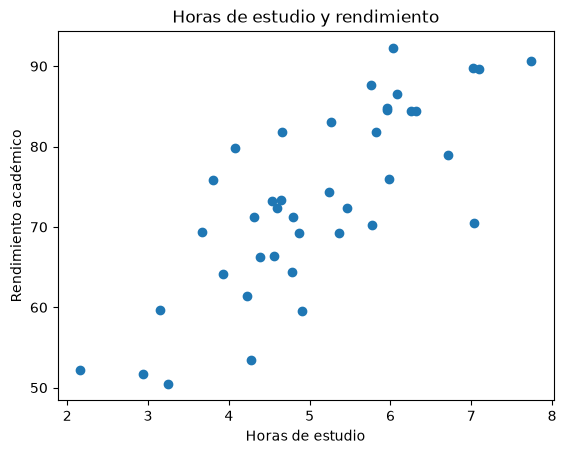

In [26]:
plt.scatter(
    datos["horas_estudio"],
    datos["rendimiento"]
)

plt.xlabel("Horas de estudio")
plt.ylabel("Rendimiento académico")
plt.title("Horas de estudio y rendimiento")

plt.show()

In [27]:
datos[["horas_estudio", "rendimiento"]].cov()

,horas_estudio,rendimiento
horas_estudio,1.544461,11.055606
rendimiento,11.055606,130.567122


In [28]:
datos[["horas_estudio", "rendimiento"]].corr()

,horas_estudio,rendimiento
horas_estudio,1.000000,0.778533
rendimiento,0.778533,1.000000


En esta muestra simulada existe una asociación lineal positiva relativamente fuerte entre horas de estudio y rendimiento.
Observa cuidadosamente la palabra utilizada:

asociación.

No hemos demostrado:

estudiar más causa mejor rendimiento.

Podrían intervenir motivación, capacidad previa, apoyo familiar, hábitos, autoeficacia, etc.

Esta distinción será permanente durante todo el curso:

**asociación  no es causalidad**

### Y aquí aparece la regresión